# Phase 1: Business Understanding
**CRISP-DM Purpose:** Define the business problem, objectives, and success criteria before any data work begins.

---

## Problem Statement

| | |
|---|---|
| **Business Question** | Which In Progress residents are on track for successful reintegration, and which are at risk of stalling — so social workers and board members can prioritize interventions before a case goes On Hold or regresses? |
| **Target Variable** | `reintegration_ready` (engineered from `reintegration_status`) |
| **Problem Type** | Binary Classification |
| **Positive Class** | `1 = Ready` (Completed reintegration) |
| **Negative Class** | `0 = Not Ready` (Not Started or On Hold) |
| **Inference scope** | In Progress residents (21) — scored as unknowns at inference time |
| **Output** | Readiness score (0–1 probability) per In Progress resident, written to `resident_reintegration_scores` in Supabase |
| **Consumer** | Social workers (operational) and board members / admins (reporting and resource allocation) |

---

## Feasibility Assessment

| Criterion | Assessment |
|---|---|
| **Practical Impact** | Identifying which In Progress residents are drifting toward On Hold or stalling allows the team to intervene early — redirecting session focus, escalating family contact, or adjusting intervention plans — before a case regresses. |
| **Data Availability** | Seven tables available: `residents`, `health_wellbeing_records`, `education_records`, `process_recordings`, `home_visitations`, `intervention_plans`, `incident_reports`. All 60 residents have records in most tables. |
| **Analytical Feasibility** | Rich behavioral signals exist (session progress, family cooperation, incident history, health trends). Dataset is small (60 residents, 39 in training set) — models must be heavily regularized and results interpreted with wide confidence intervals. |
| **Label Feasibility** | `Completed` residents provide clean positive-class ground truth. `Not Started` and `On Hold` provide the negative class. **In Progress residents are excluded from training** and treated as unknowns to be scored — avoiding the label leakage of treating partially-completed cases as "Ready". |

---

## Model Framing

**Retrospective characterization model.**

We train on residents whose outcome is already known (`Completed` vs `Not Started / On Hold`) using their full accumulated history. The model learns the behavioral and profile patterns that distinguish residents who successfully completed reintegration from those who did not progress.

We then apply this model to **In Progress** residents — who have partial but meaningful history — to score their current trajectory.

### Important caveat
This is not a pure prospective prediction model. `Completed` residents have fully accumulated history, while `In Progress` residents have partial history. The model's score for an In Progress resident should be interpreted as: *"Given what we know so far, does this resident's profile resemble residents who ultimately completed reintegration?"*

This is acknowledged in the executive summary and should be communicated to social workers when they review the score list.

---

## Success Criteria

| | |
|---|---|
| **Primary metric** | Precision on the positive class — minimize false positives (wrongly flagging a Not Ready resident as Ready) |
| **Secondary metric** | F1 — balance precision against catching genuinely ready residents |
| **Minimum acceptable Precision** | ≥ 0.75 — when the model says "Ready", it should be right at least 75% of the time |
| **Minimum acceptable F1** | ≥ 0.70 |
| **Baseline to beat** | Majority-class precision (computed below) |

> **Why Precision over Recall?**  
> The team confirmed that incorrectly advancing a resident toward reintegration prematurely is the more costly error. A false positive — flagging a Not Ready resident as Ready — risks premature reintegration decisions. A false negative (missing a Ready resident) means they stay in care slightly longer, which is a lower-cost outcome.

---

## Error Cost Analysis

| Error Type | Scenario | Estimated Cost |
|---|---|---|
| **False Positive** | Model says Ready → team prioritizes reintegration steps → resident is not actually ready → premature transition or failed placement | **High** — risks the resident's wellbeing and wastes case resources |
| **False Negative** | Model says Not Ready → team deprioritizes → resident stays in care longer | **Medium** — delayed outcome, but resident remains safe |

**Implication:** Optimize for Precision. Accept a lower recall rate (missing some genuinely ready residents) to avoid premature reintegration signals.

---

## Stakeholder Impact

| | |
|---|---|
| **Primary operational users** | Social workers — use the score to prioritize which In Progress cases need closer attention or intervention adjustment |
| **Secondary users** | Admins and board members — use aggregate scores for reporting, resource allocation, and case conference preparation |
| **Decisions automated** | None — all reintegration decisions remain with the social work team |
| **Human-in-the-loop** | Always — model surfaces a readiness score, humans decide next steps |
| **Prediction sink** | `resident_reintegration_scores` table in Supabase, keyed by `resident_id` |
| **Known failure patterns** | None specifically documented — uncovering failure patterns is part of the model's value |

---

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))

from src.config import LABEL_MAP, TARGET
from src.data_io import load_all_csvs

sns.set_theme(style='whitegrid', palette='muted')

tables = load_all_csvs()
residents = tables['residents']

print(f'Residents loaded: {len(residents)} rows × {residents.shape[1]} columns')

Residents loaded: 60 rows × 49 columns


In [6]:
# Full reintegration_status distribution
status_counts = residents['reintegration_status'].value_counts()
print('reintegration_status distribution:')
print(status_counts)

# Training vs inference split
training_mask  = residents['reintegration_status'].isin(['Completed', 'Not Started', 'On Hold'])
inference_mask = residents['reintegration_status'] == 'In Progress'

train_df = residents[training_mask].copy()
infer_df = residents[inference_mask].copy()

train_df[TARGET] = train_df['reintegration_status'].map(LABEL_MAP)
label_counts = train_df[TARGET].value_counts()
ratio = label_counts.max() / label_counts.min()

print(f'\n--- Training set ({len(train_df)} residents) ---')
print(label_counts.rename({1: 'Ready / Completed (1)', 0: 'Not Ready / Stalled (0)'}))
print(f'Class imbalance ratio : {ratio:.2f}:1')

if ratio >= 4:
    print('⚠ Imbalance ≥ 4:1 — class_weight="balanced" required.')
else:
    print('✓ Imbalance < 4:1 — class_weight="balanced" applied as precaution.')

print(f'\n--- Inference set ({len(infer_df)} residents) ---')
print('These residents will be scored, not trained on.')

reintegration_status distribution:
reintegration_status
In Progress    21
Completed      19
On Hold        13
Not Started     7
Name: count, dtype: int64

--- Training set (39 residents) ---
reintegration_ready
Not Ready / Stalled (0)    20
Ready / Completed (1)      19
Name: count, dtype: int64
Class imbalance ratio : 1.05:1
✓ Imbalance < 4:1 — class_weight="balanced" applied as precaution.

--- Inference set (21 residents) ---
These residents will be scored, not trained on.


In [7]:
# Majority-class baseline metrics
majority_class = label_counts.idxmax()
baseline_acc   = label_counts.max() / label_counts.sum()

# If model always predicts majority class:
# Precision on positive class = TP / (TP + FP)
# Always-positive: TP = n_positive, FP = n_negative → precision = n_pos/n_total
# Always-negative: TP = 0 → precision = 0 (undefined, set to 0)
n_pos = label_counts.get(1, 0)
n_neg = label_counts.get(0, 0)
baseline_precision_always_pos = n_pos / (n_pos + n_neg)

print('=== Baselines to beat ===')
print(f'  Majority-class accuracy         : {baseline_acc:.1%}  (always predict class {majority_class})')
print(f'  Always-positive precision       : {baseline_precision_always_pos:.1%}')
print(f'  Random precision (class balance): {n_pos / (n_pos + n_neg):.1%}')
print()
print(f'  → Model must achieve Precision ≥ 0.75 and F1 ≥ 0.70 to be useful.')

=== Baselines to beat ===
  Majority-class accuracy         : 51.3%  (always predict class 0)
  Always-positive precision       : 48.7%
  Random precision (class balance): 48.7%

  → Model must achieve Precision ≥ 0.75 and F1 ≥ 0.70 to be useful.


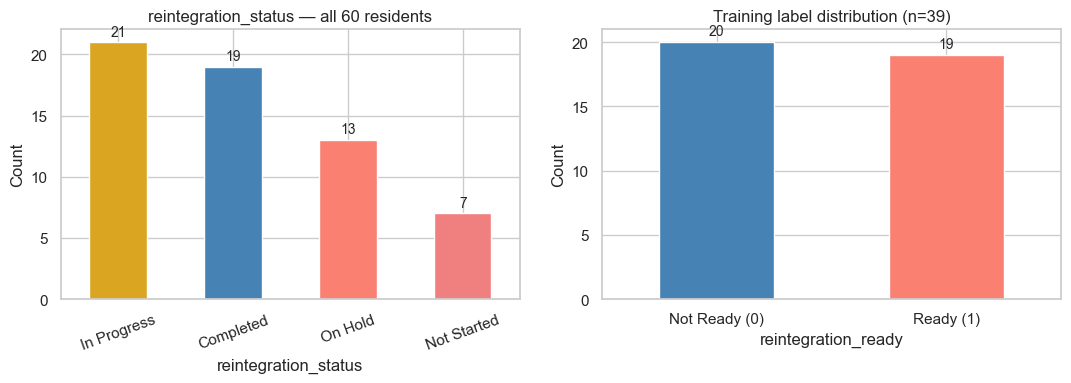


Note: 21 In Progress residents are shown in gold above.
They are excluded from training and will receive a readiness score at inference.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Full status distribution
colors = {'Completed': 'steelblue', 'In Progress': 'goldenrod',
          'On Hold': 'salmon', 'Not Started': 'lightcoral'}
status_counts.plot(
    kind='bar', ax=axes[0],
    color=[colors.get(s, 'gray') for s in status_counts.index],
    rot=20, edgecolor='white',
)
axes[0].set_title('reintegration_status — all 60 residents')
axes[0].set_ylabel('Count')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 int(bar.get_height()), ha='center', va='bottom', fontsize=10)

# Training label distribution
label_counts.rename({1: 'Ready (1)', 0: 'Not Ready (0)'}).plot(
    kind='bar', ax=axes[1],
    color=['steelblue', 'salmon'], rot=0, edgecolor='white',
)
axes[1].set_title(f'Training label distribution (n={len(train_df)})')
axes[1].set_ylabel('Count')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 int(bar.get_height()), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f'\nNote: {len(infer_df)} In Progress residents are shown in gold above.')
print('They are excluded from training and will receive a readiness score at inference.')

## Phase Evidence & Assumptions

| Decision | Source | Notes |
|---|---|---|
| Precision as primary metric | User-confirmed | Premature reintegration is the higher-cost error |
| In Progress residents excluded from training | Design decision | Avoids treating partially-completed cases as "Ready" — clean labels only |
| Training on all 60 residents' history | Design decision | Completed and stalled cases provide real outcome signals |
| Human-in-the-loop always | User-confirmed | Model surfaces score; social workers decide |
| No known historical failure patterns | User-confirmed | Model is partly intended to uncover these patterns |
| Small dataset (~39 training samples) | Observed | Heavy regularization required; wide confidence intervals expected |

---

## Phase 1 Conclusion

**Problem is well-defined and feasible.**

We are building a binary classifier to score In Progress residents by their probability of successful reintegration. The model trains on the 39 residents with known outcomes (Completed vs Not Started/On Hold) and scores the 21 In Progress residents. 

Key risks:
- **Small training set** (~39 samples): performance estimates carry wide confidence intervals. Cross-validation is the primary reliability signal.
- **Retrospective framing**: Completed residents have fully accumulated history; In Progress residents have partial history. Scores should be interpreted as trajectory signals, not hard predictions.

Success thresholds: **Precision ≥ 0.75**, **F1 ≥ 0.70** on held-out data.

---
**Proceed to Phase 2: Data Understanding →** `02_data_understanding.ipynb`